# Sparse autoencoder

In [24]:
import torch
from torch import nn
from torch.utils import data
import matplotlib.pyplot as plt
from config import (
    SEED,
    TRAIN_BS,
    VAL_BS,
    COLORED_PROPORTION,
    CLS_EPOCHS
)
from models import ClsModel, SAE, TopkSAE, TrimmedClsModel
import train_utils
import plot_utils
import metrics
import os
import tqdm
import data_utils
import functools

In [174]:
SAE_FEATURES_LAYER = -5	# Output of this layer will be used as input for the SAE
SAE_HIDDEN_DIM = 64*4
SAE_ALPHA = 0
SAE_TOPK = 6    # Only applies when using TopKSAE
SAE_BS = 128

In [26]:
plt.style.use('default')

device = "cuda" if torch.cuda.is_available() else "mps"

In [27]:
train_dataset = torch.load("./data/train_dataset.pt", weights_only=False)
val_dataset = torch.load("./data/val_dataset.pt", weights_only=False)
clean_val_dataset = torch.load("./data/clean_val_dataset.pt", weights_only=False)
fully_colored_val_dataset = torch.load("./data/fully_colored_val_dataset.pt", weights_only=False)
colors_flipped_val_dataset = torch.load("./data/colors_flipped_val_dataset.pt", weights_only=False)

train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
fully_colored_val_dataloader = data.DataLoader(fully_colored_val_dataset, batch_size=VAL_BS)
colors_flipped_val_dataloader = data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS)

In [28]:
model = ClsModel()

model.load_state_dict(torch.load(f"./weights/cls_model_{COLORED_PROPORTION}.pt"))
model.to(device)

ClsModel(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): Tanh()
    (3): Linear(in_features=512, out_features=64, bias=True)
    (4): Tanh()
    (5): Linear(in_features=64, out_features=8, bias=True)
    (6): Tanh()
    (7): Linear(in_features=8, out_features=10, bias=True)
  )
)

In [29]:
sae_input_shape = model.fc[SAE_FEATURES_LAYER].out_features

In [30]:
sae_train_dataset = data_utils.generate_sae_dataset(model, train_dataset, layer_idx=SAE_FEATURES_LAYER, device=device)
sae_val_dataset = data_utils.generate_sae_dataset(model, val_dataset, layer_idx=SAE_FEATURES_LAYER, device=device)

sae_train_dataloader = data.DataLoader(sae_train_dataset, SAE_BS, shuffle=True)
sae_val_dataloader = data.DataLoader(sae_val_dataset, SAE_BS, shuffle=False)

100%|██████████| 12000/12000 [00:06<00:00, 1953.38it/s]


In [62]:
def sae_criterion_fn(outputs, targets, hidden, alpha=0.5):
    """
    SAE criterion that applies both L1 loss on hidden SAE vector as well as L2 reconstruction loss.
    
    Args:
		outputs: Output of the SAE decoder.
        targets: Target used for reconstruction loss.
        hidden: Sparse hidden vector, output of the SAE's encoder.
        alpha (optional): Weight applied to sparsity loss.
    Returns:
		torch.Tensor: Combined sparsity and reconstruction loss.
    """
    mae = torch.mean(torch.abs(hidden))	# L1 Loss to ensure hidden layer sparsity
    reconstruction_loss = torch.mean((outputs-targets)**2)
    return reconstruction_loss+alpha*mae

In [175]:
torch.manual_seed(SEED)	# Set random seed for weights reproducibility

if SAE_TOPK > 0:
	sae_model = TopkSAE(sae_input_shape, SAE_HIDDEN_DIM, topk=SAE_TOPK)
	sae_criterion = nn.MSELoss()
else:
	sae_model = SAE(sae_input_shape, SAE_HIDDEN_DIM)
	sae_criterion = functools.partial(sae_criterion_fn, alpha=SAE_ALPHA)

sae_model.to(device)
sae_optimizer = torch.optim.Adam(sae_model.parameters(), lr=1e-3)


In [176]:
train_utils.sae_train(sae_model, sae_train_dataloader, sae_val_dataloader, sae_criterion, sae_optimizer, epochs=200, device=device)

Evaluating: 100%|██████████| 94/94 [00:00<00:00, 372.95it/s]


Epoch 1/200 - Train Loss: 0.0378, Val Loss: 0.0120, Train active neurons: 6.0000, Val active neurons: 6.0000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 497.39it/s]


Epoch 2/200 - Train Loss: 0.0108, Val Loss: 0.0096, Train active neurons: 6.0000, Val active neurons: 6.0000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 371.95it/s]


...

Evaluating: 100%|██████████| 94/94 [00:00<00:00, 489.04it/s]


Epoch 199/200 - Train Loss: 0.0035, Val Loss: 0.0034, Train active neurons: 5.9998, Val active neurons: 6.0000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 341.08it/s]

Epoch 200/200 - Train Loss: 0.0034, Val Loss: 0.0034, Train active neurons: 5.9999, Val active neurons: 6.0000


([0.03783141862104336,
  0.010812063915034135,
  0.00917206505810221,
  0.008589916086445252,
  0.008164295453578234,
  0.007851888589560986,
  0.00793034628406167,
  0.007588676379372676,
  0.007428066951533158,
  0.007425378959625959,
  0.007235698295136293,
  0.007239091951400042,
  0.007126480848838886,
  0.0069889185664554435,
  0.007157873916129271,
  0.007032202780246735,
  0.007124300763010979,
  0.007101574623336395,
  0.007091166843970617,
  0.006774264646073182,
  0.006723795985182126,
  0.006715563180545966,
  0.0067075196752945584,
  0.006687689557671547,
  0.007101405588289102,
  0.007289832429339488,
  0.0071443395341436065,
  0.007029246081908544,
  0.006831270056466262,
  0.007068987270196279,
  0.006958616898705562,
  0.006903596011300882,
  0.006837632092336813,
  0.006603307324151198,
  0.006955220929036538,
  0.0067279129847884174,
  0.006963832305123409,
  0.006745966910074155,
  0.0065073639440039795,
  0.006508886198202769,
  0.006524845176686844,
  0.0063623947

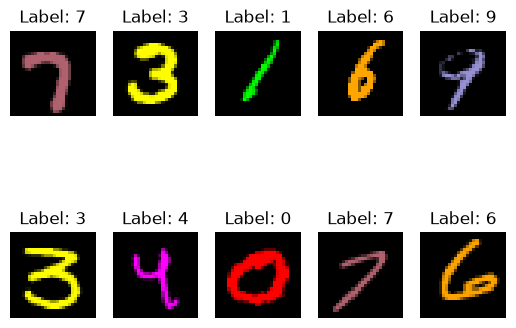

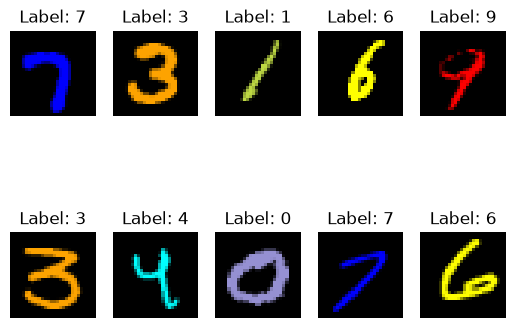

In [177]:
plot_utils.show_from_dataset(val_dataset, range(0, 10))
plot_utils.show_from_dataset(colors_flipped_val_dataset, range(0, 10))

In [178]:
for i in range(10):
	input, target = val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:SAE_FEATURES_LAYER+1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, SAE_TOPK)
	print(f"Colors not flipped {i}: {indices}")

	input, target = colors_flipped_val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:SAE_FEATURES_LAYER+1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, SAE_TOPK)
	print(f"Colors flipped {i}: {indices}")

Colors not flipped 0: tensor([[233, 199, 170,  42,  32, 144]], device='mps:0')
Colors flipped 0: tensor([[ 78,  42, 181, 218, 233, 190]], device='mps:0')
Colors not flipped 1: tensor([[150,  32, 217, 199, 233,  64]], device='mps:0')
Colors flipped 1: tensor([[150,  32, 217, 199, 170, 233]], device='mps:0')
Colors not flipped 2: tensor([[ 35, 150, 110,  31, 103, 224]], device='mps:0')
Colors flipped 2: tensor([[150, 197, 245,  31, 113,  35]], device='mps:0')
Colors not flipped 3: tensor([[150,   6, 170, 217, 245, 140]], device='mps:0')
Colors flipped 3: tensor([[150,   6, 217, 245,  38, 170]], device='mps:0')
Colors not flipped 4: tensor([[ 42, 233,  85,  32,  53, 218]], device='mps:0')
Colors flipped 4: tensor([[170, 199,  85, 245, 103,  34]], device='mps:0')
Colors not flipped 5: tensor([[150,  32, 217, 199,  64, 144]], device='mps:0')
Colors flipped 5: tensor([[150,  32, 199, 217, 170, 115]], device='mps:0')
Colors not flipped 6: tensor([[170,  42,  85,  78,  32, 220]], device='mps:0

In [179]:
from torch.return_types import topk


@torch.no_grad()
def get_representatives(cls_model, sae_model, dataloader, n_representatives=10, topk_value=0):
	"""
	Given classification model and sae model returns n_representatives examples from dataset which activate each SAE hidden layer neurons the most
	"""
	sae_hidden_dim = sae_model.hidden_dim

	top_values = torch.full((sae_hidden_dim, n_representatives), -float('inf'), device=device)

	representatives = torch.full((sae_hidden_dim, n_representatives), -1, dtype=torch.long, device=device)

	current_img_offset = 0

	for inputs, targets in tqdm.tqdm(dataloader):
		inputs = inputs.to(device)
		bs = inputs.size(0)
		
		embeddings = cls_model.fc[:SAE_FEATURES_LAYER+1](inputs)
		
		output, hidden = sae_model(embeddings)

		if topk_value:
			values, indices = torch.topk(hidden, topk_value, dim=1)
			sparse_hidden = torch.zeros_like(hidden)
			sparse_hidden.scatter_(1, indices, values)
			hidden = sparse_hidden
			
		batch_indices = torch.arange(current_img_offset, current_img_offset + bs, device=device)
		
		batch_hidden = hidden.T 
		
		# Create dataset indices for the current batch
		batch_indices = batch_indices.unsqueeze(0).expand(sae_hidden_dim, bs)
		
		# Concatenate the running top N with the new batch
		combined_values = torch.cat([top_values, batch_hidden], dim=1)
		combined_indices = torch.cat([representatives, batch_indices], dim=1)
		
		# Find the global winners so far
		top_values, topk_args = torch.topk(combined_values, k=n_representatives, dim=1)
		
		# Gather the winning image indices
		representatives = torch.gather(combined_indices, dim=1, index=topk_args)
		
		current_img_offset += bs

	return representatives, top_values

In [180]:
n_representatives = 10

clean_val_representatives, clean_val_top_values = get_representatives(model, sae_model, clean_val_dataloader, n_representatives, topk_value=SAE_TOPK)
fully_colored_val_representatives, fully_colored_val_top_values = get_representatives(model, sae_model, fully_colored_val_dataloader, n_representatives, topk_value=SAE_TOPK)
colors_flipped_val_representatives, colors_flipped_val_top_values = get_representatives(model, sae_model, colors_flipped_val_dataloader, n_representatives, topk_value=SAE_TOPK)

100%|██████████| 375/375 [00:00<00:00, 697.16it/s]


Showing representative samples for 5 out of 256 sae neurons
Neuron: 0


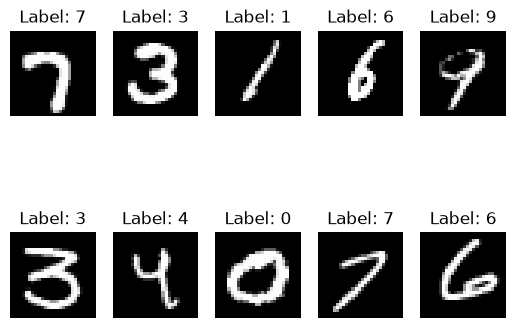

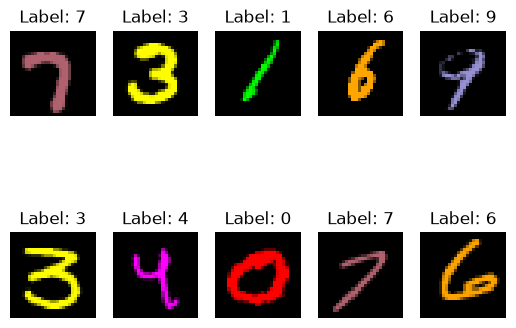

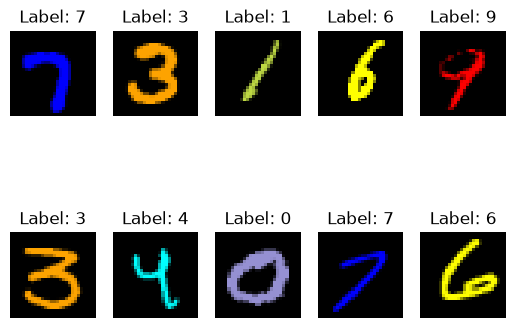

Neuron: 1


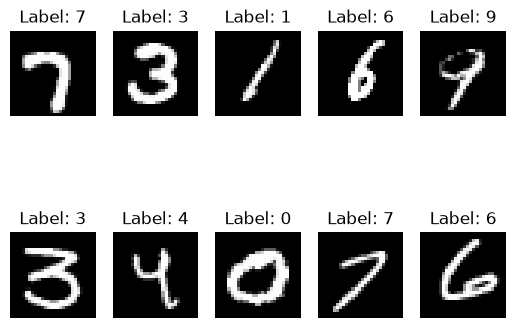

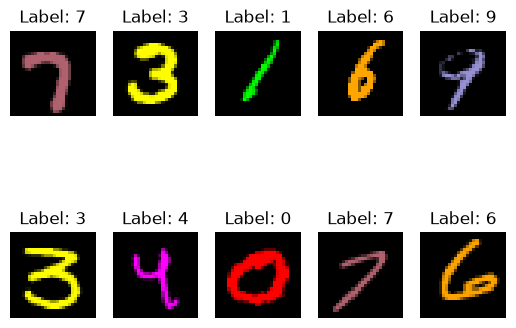

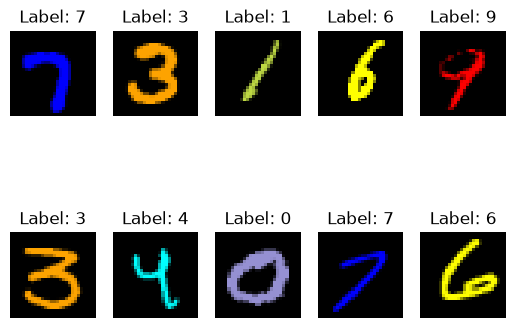

Neuron: 2


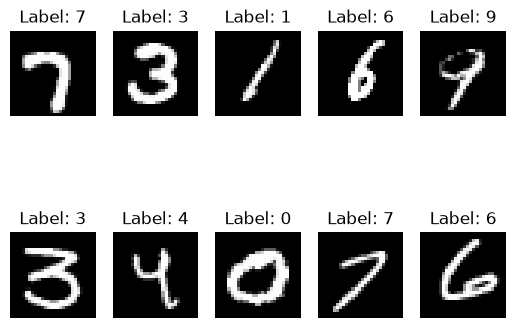

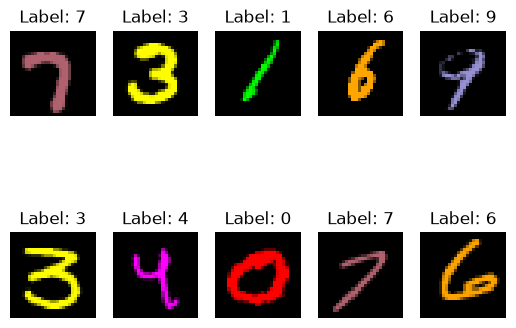

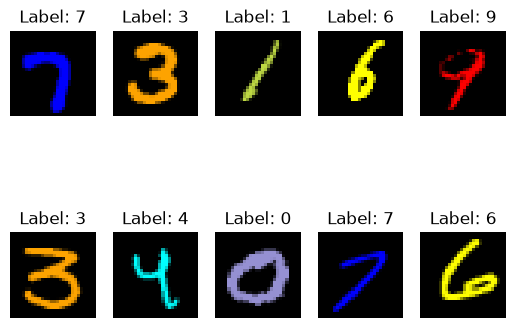

Neuron: 3


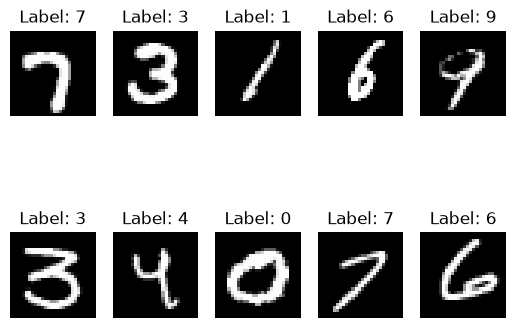

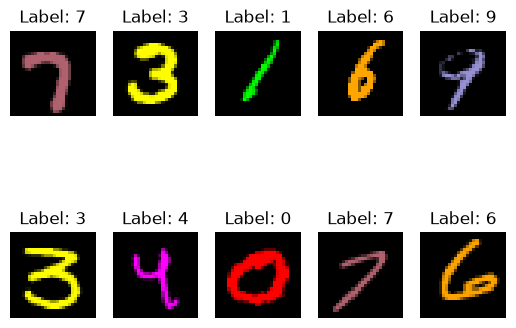

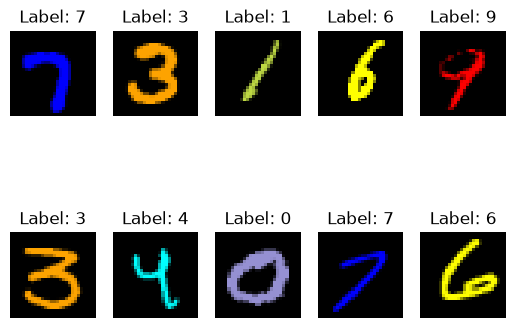

Neuron: 4


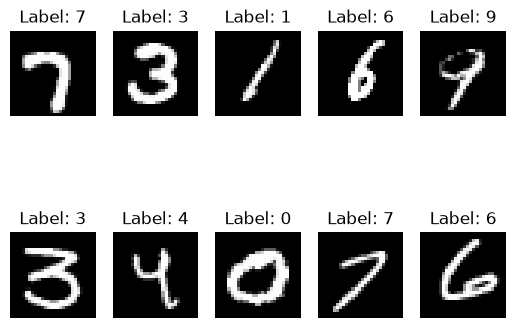

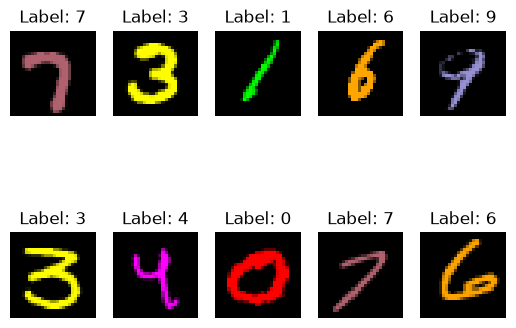

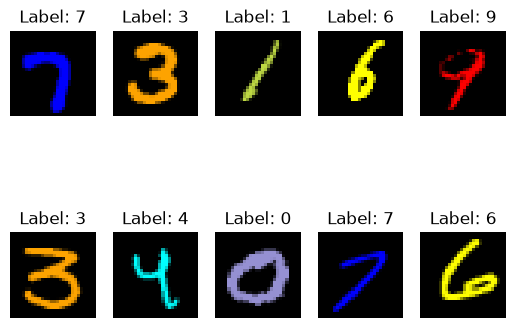

In [205]:
neurons_to_show = min(5, SAE_HIDDEN_DIM)
print(f"Showing representative samples for {neurons_to_show} out of {SAE_HIDDEN_DIM} sae neurons")

for neuron_idx in range(neurons_to_show):
    print(f"Neuron: {neuron_idx}")
    plot_utils.show_from_dataset(clean_val_dataset, clean_val_representatives[neuron_idx].tolist())
    plot_utils.show_from_dataset(fully_colored_val_dataset, fully_colored_val_representatives[neuron_idx].tolist())
    plot_utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

# Check representatives for features activating at specific dataset examples

Label: 9


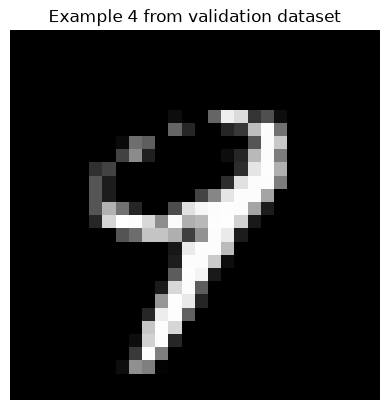

TOP 6 features for example 4: [42, 150, 233, 85, 170, 38]

Representative samples for feature 42:
Values: [47.25812911987305, 45.9981575012207, 45.47593307495117, 45.405235290527344, 45.36021423339844, 45.13439178466797, 45.0398063659668, 44.97795486450195, 44.96699523925781, 44.784202575683594]


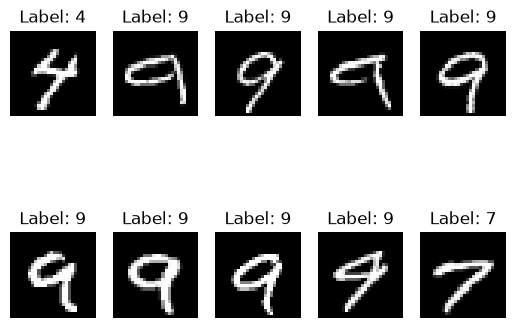

Values: [49.950347900390625, 49.63688278198242, 49.47541427612305, 49.38039779663086, 49.35603713989258, 49.26902770996094, 49.26369857788086, 49.21255874633789, 49.11429214477539, 49.11236572265625]


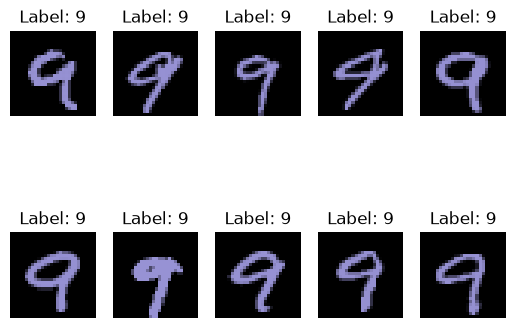

Values: [37.05521774291992, 36.94758987426758, 36.82340621948242, 36.63364791870117, 36.37770462036133, 36.239715576171875, 36.093971252441406, 35.87834930419922, 35.81850051879883, 35.721378326416016]


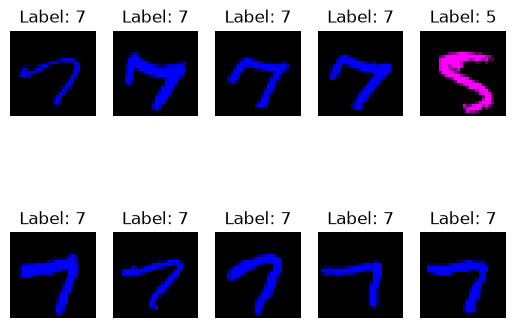


Representative samples for feature 150:
Values: [32.3901252746582, 31.664073944091797, 31.63519859313965, 31.579822540283203, 31.45006561279297, 31.43817901611328, 31.381244659423828, 31.30675506591797, 31.157325744628906, 31.120609283447266]


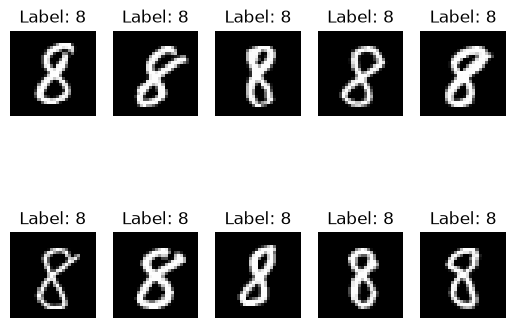

Values: [50.36232376098633, 50.35758590698242, 50.290122985839844, 50.25045394897461, 50.13038635253906, 50.06499099731445, 49.81623458862305, 49.80707550048828, 49.79336929321289, 49.78000259399414]


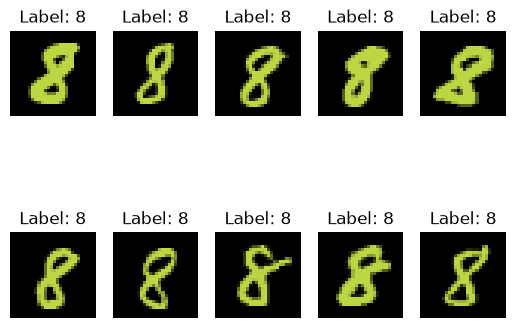

Values: [46.47397232055664, 46.08375549316406, 46.051177978515625, 45.99839401245117, 45.874568939208984, 45.755855560302734, 45.561981201171875, 45.47278594970703, 45.43227767944336, 45.34966278076172]


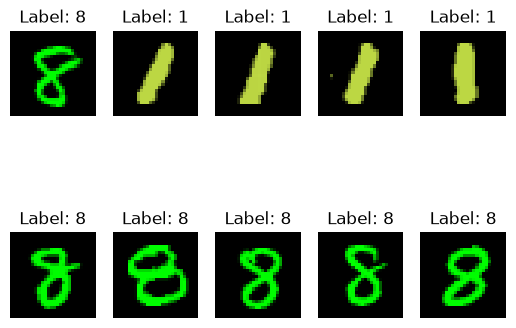


Representative samples for feature 233:
Values: [44.95130157470703, 42.465370178222656, 41.27703857421875, 41.20426559448242, 40.99040985107422, 40.64089584350586, 40.214263916015625, 40.208168029785156, 40.19232177734375, 39.96659469604492]


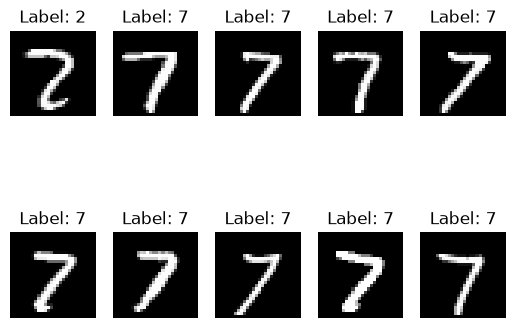

Values: [40.359615325927734, 39.101627349853516, 38.8541145324707, 38.81772232055664, 38.745704650878906, 38.49859619140625, 38.441349029541016, 38.330223083496094, 38.312278747558594, 38.25762939453125]


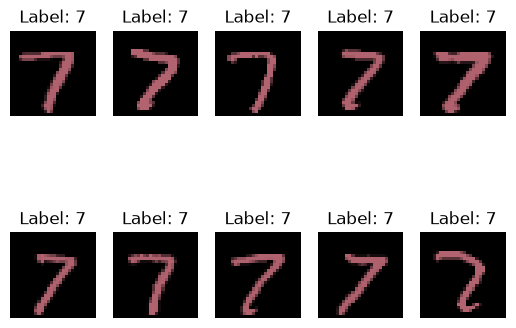

Values: [41.919673919677734, 36.82763671875, 36.48343276977539, 36.286949157714844, 35.83400344848633, 35.72567367553711, 35.44947052001953, 35.12693786621094, 33.80274963378906, 33.61241912841797]


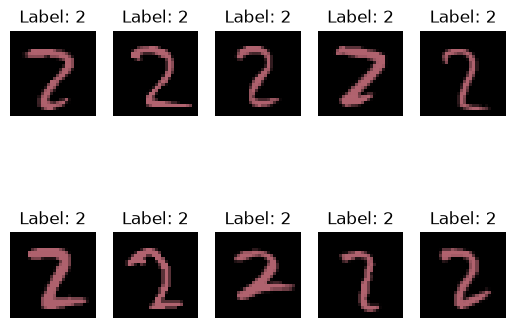


Representative samples for feature 85:
Values: [17.791515350341797, 17.349384307861328, 17.299453735351562, 17.052959442138672, 16.92629051208496, 16.59878921508789, 16.51874351501465, 16.391366958618164, 16.38681411743164, 16.153207778930664]


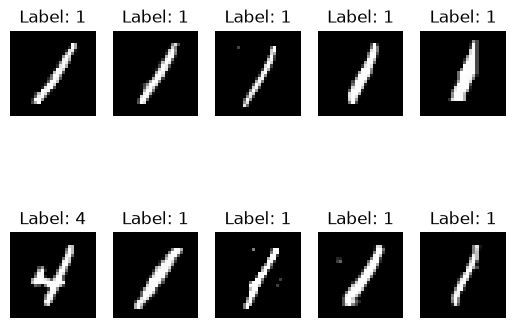

Values: [31.661821365356445, 30.343843460083008, 30.093441009521484, 29.607322692871094, 29.36691665649414, 29.269712448120117, 29.254732131958008, 29.145519256591797, 29.09941864013672, 29.055583953857422]


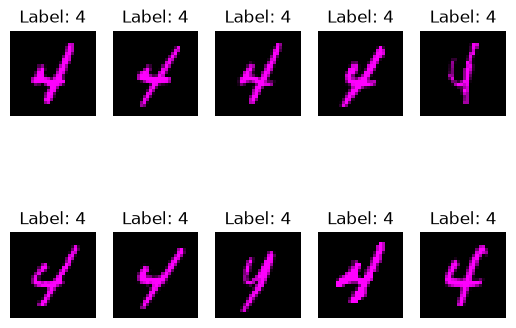

Values: [25.655437469482422, 23.584997177124023, 23.05091667175293, 23.0048770904541, 22.99146270751953, 22.81637191772461, 22.535789489746094, 22.529985427856445, 22.121315002441406, 22.08452796936035]


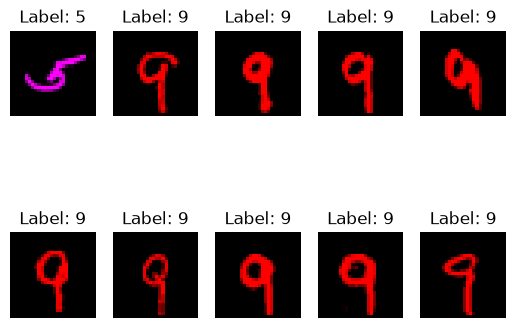


Representative samples for feature 170:
Values: [30.98206901550293, 30.94963836669922, 30.861278533935547, 29.7307186126709, 29.710031509399414, 29.037973403930664, 28.895158767700195, 28.75242805480957, 28.6972713470459, 28.585186004638672]


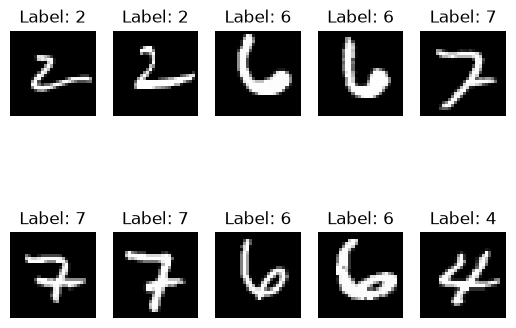

Values: [59.29539489746094, 59.101470947265625, 58.93056106567383, 58.85784912109375, 58.82068634033203, 58.80083465576172, 58.77737045288086, 58.77336120605469, 58.76387023925781, 58.7547721862793]


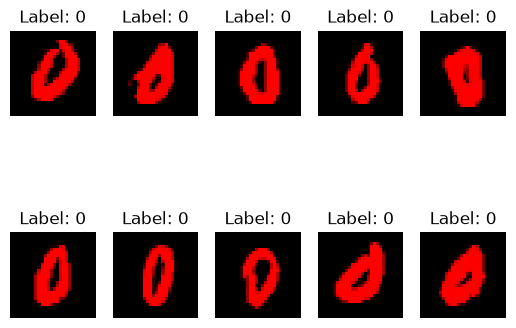

Values: [60.32771682739258, 60.013099670410156, 59.680824279785156, 59.66610336303711, 59.448143005371094, 59.342586517333984, 59.32740020751953, 59.21021270751953, 59.17936706542969, 59.07392883300781]


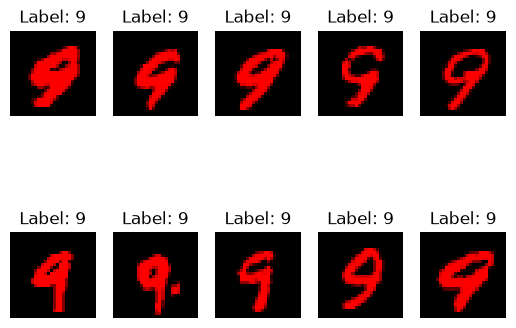


Representative samples for feature 38:
Values: [18.476764678955078, 17.97514533996582, 17.87613296508789, 17.237228393554688, 16.983306884765625, 16.553747177124023, 16.509281158447266, 16.342010498046875, 16.28826904296875, 16.193178176879883]


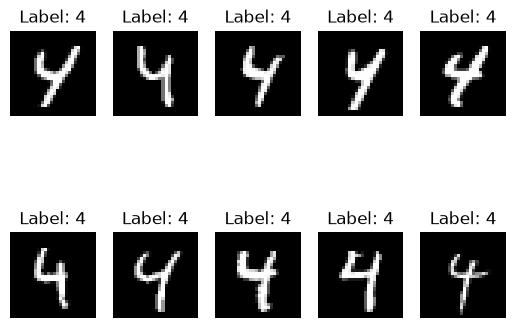

Values: [20.464174270629883, 20.335107803344727, 20.26898956298828, 20.04215431213379, 19.693105697631836, 19.575294494628906, 19.509614944458008, 19.451257705688477, 19.449644088745117, 19.339021682739258]


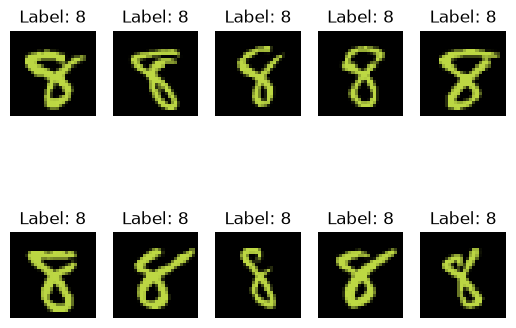

Values: [20.855510711669922, 17.809465408325195, 17.316001892089844, 17.225553512573242, 16.989274978637695, 16.636167526245117, 16.384889602661133, 16.361478805541992, 16.24238395690918, 16.14440155029297]


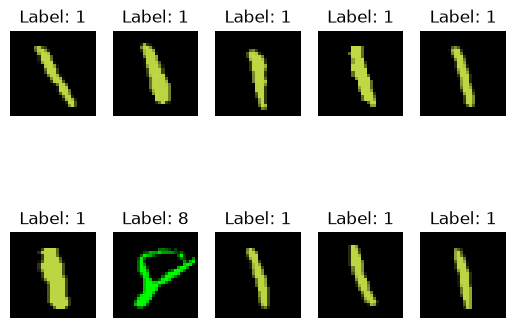

In [188]:
example_idx = 4
top_k = SAE_TOPK
experiment_dataset = clean_val_dataset  # Change this to colors_flipped_val_dataset to test on the colors flipped dataset

print(f"Label: {experiment_dataset[example_idx][1]}")

inputs = experiment_dataset[example_idx][0].unsqueeze(0).to(device)
sae_input = model.fc[:SAE_FEATURES_LAYER+1](inputs)

sae_output, sae_hidden = sae_model(sae_input)
topk_features = torch.topk(sae_hidden, top_k).indices.squeeze().tolist()

plt.imshow(inputs.squeeze().cpu().permute(1, 2, 0))
plt.axis('off')
plt.title(f"Example {example_idx} from validation dataset")
plt.show()

print(f"TOP {top_k} features for example {example_idx}: {topk_features}")

for i in range(top_k):
    print("\n==============")
    print(f"Representative samples for feature {topk_features[i]}:")
    print(f"Values: {clean_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(clean_val_dataset, clean_val_representatives[topk_features[i]].tolist())
    print(f"Values: {fully_colored_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(fully_colored_val_dataset, fully_colored_val_representatives[topk_features[i]].tolist())
    print(f"Values: {colors_flipped_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[topk_features[i]].tolist())

In [206]:
checkpoint_path = f"./weights/sae_model__topk_{SAE_TOPK}__hidden_{SAE_HIDDEN_DIM}__cp_{COLORED_PROPORTION}.pt"

if not os.path.exists(checkpoint_path):
	torch.save(sae_model.state_dict(), checkpoint_path)

# Validate model with SAE neurons killed that ativate for certain colors

In [193]:
neurons_to_kill = [31, 34, 35, 38, 78, 100, 110, 118, 170, 181, 197, 203, 220, 221, 233, 235]

In [198]:
trimmed_model = TrimmedClsModel(model, sae_model, neurons_to_kill, sae_features_layer=SAE_FEATURES_LAYER)

cls_criterion = nn.CrossEntropyLoss()

In [ ]:
metrics_calculator = metrics.MetricsCalculator(num_classes=10, average=None)

In [204]:
print("=========== BASELINE ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")

print("=========== TRIMMED ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(trimmed_model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(trimmed_model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(trimmed_model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")


=========== BASELINE ===========


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 331.59it/s]


Performance on clean validation set:
Clean Val Loss: 0.015241414661208789, Accuracy: tensor([0.9705, 0.9199, 0.9027, 0.7382, 0.8134, 0.8192, 0.7880, 0.8707, 0.8333,
        0.9168]), Precision: tensor([0.9705, 0.9199, 0.9027, 0.7382, 0.8134, 0.8192, 0.7880, 0.8707, 0.8333,
        0.9168]), Recall: tensor([0.9705, 0.9199, 0.9027, 0.7382, 0.8134, 0.8192, 0.7880, 0.8707, 0.8333,
        0.9168]), F1 Score: tensor([0.9013, 0.9484, 0.8591, 0.8272, 0.8308, 0.7939, 0.8623, 0.8738, 0.8340,
        0.8338]), AUPRC: tensor([0.9622, 0.9808, 0.9220, 0.8691, 0.8938, 0.8188, 0.9333, 0.9535, 0.9011,
        0.8876]), AUROC: tensor([0.9947, 0.9939, 0.9792, 0.9444, 0.9721, 0.9556, 0.9831, 0.9880, 0.9765,
        0.9785])
Performance on fully colored validation set:
Fully Colored Val Loss: 0.00024403737605704616, Accuracy: tensor([1.0000, 1.0000, 1.0000, 0.9984, 1.0000, 1.0000, 1.0000, 1.0000, 0.9991,
        0.9992]), Precision: tensor([1.0000, 1.0000, 1.0000, 0.9984, 1.0000, 1.0000, 1.0000, 1.0000, 0

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 272.82it/s]

Performance on clean validation set:
Clean Val Loss: 0.040313775435090064, Accuracy: tensor([0.8641, 0.7678, 0.6779, 0.5669, 0.3339, 0.8201, 0.7035, 0.0040, 0.8427,
        0.9782]), Precision: tensor([0.8641, 0.7678, 0.6779, 0.5669, 0.3339, 0.8201, 0.7035, 0.0040, 0.8427,
        0.9782]), Recall: tensor([0.8641, 0.7678, 0.6779, 0.5669, 0.3339, 0.8201, 0.7035, 0.0040, 0.8427,
        0.9782]), F1 Score: tensor([0.8397, 0.8240, 0.7240, 0.6535, 0.4921, 0.6712, 0.7451, 0.0079, 0.7706,
        0.5292]), AUPRC: tensor([0.7251, 0.9248, 0.7879, 0.6834, 0.7171, 0.6798, 0.7085, 0.8250, 0.8689,
        0.6923]), AUROC: tensor([0.9553, 0.9748, 0.9554, 0.8811, 0.9196, 0.9350, 0.9350, 0.9406, 0.9727,
        0.9605])
Performance on fully colored validation set:
Fully Colored Val Loss: 0.04802806063493093, Accuracy: tensor([9.5949e-01, 0.0000e+00, 4.8154e-01, 1.0000e+00, 8.5616e-04, 8.7362e-01,
        8.0236e-01, 9.5770e-03, 9.9915e-01, 9.9832e-01]), Precision: tensor([9.5949e-01, 0.0000e+00, 4.81